In [1]:
import lmfit
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import scipy.constants as const
import matplotlib as mpl


from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
from itertools import combinations
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import eigh


In [2]:
dataset_no_correction = xr.load_dataset("Data\Cross_talk_original.hdf5")
dataset_compensated = xr.load_dataset("Data\Cross_talk_corrected.hdf5")

In [3]:
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1

Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)

Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F
T = 15e-3 #K
Delta_Al = 3.4e-4*e # J

E_J = 20e9*h #Hz

In [4]:
Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm


a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

In [9]:
# Load fitted transmission data
dataset = dataset_no_correction
dataset['S21'] = dataset.S21_real + 1j*dataset.S21_imag

data2 = dataset_compensated.x0[
    dataset_compensated.y0.fillna(0).argmin('x0')
]

data2 = data2.assign_coords(
    x1=data2.x1*1.1126 -0.4 ,
    x2=data2.x2*1.0753 + 1.775
)

data2 = data2*1e-9 - f_r

In [5]:

def build_phase_hamiltonians_delta(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        # alpha: float,
        ng: float,
) -> np.ndarray:

    # Phase grid
    phis = phis * 2*np.pi
    N = len(phis)

    # -----------------   Kinetic term (finite-difference Laplacian)
    delta_phi = phis[1] - phis[0]
    # t = 1 / delta_phi**2
# ∂^2 operator
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ∂ operator
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Kinetic term
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # -------------  Potential term
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    
    EJsum = EJ4 + EJ5

    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    
    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)
    # print(EJ4eff)
    
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)
   
    delta = np.arctan2(d*np.sin(np.pi*flux2), np.cos(np.pi*flux2))
    # delta = 0
     # Initialize potential
    V = np.zeros((len(flux1), N, N), dtype=float)
   
    CJ1 = get_CJ(EJ1)
#     print(CJ3)
    CJ2 = get_CJ(EJ2)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9


    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)


    CJ3 = get_CJ(EJ3)
#     print(CJ2)

    C_mod_R = CJ3 + CJ45

    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9


    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff


    V = np.zeros((len(flux1), N, N), dtype=float)
    
    CPR_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    CPR_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    CPR_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid - delta)/2)**2)
    CPR_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid - delta)/2)**2))

     # Potential energy at each phi for each flux
    V_phi = -(E_L * CPR_L + E_R * CPR_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])   # shape (M, N, N)

    # Add kinetic energy
    H_all = V + T[None, :, :]   # shape (M, N, N)

    return H_all, D1, phis


In [6]:

def build_phase_hamiltonians_delta(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        # alpha: float,
        ng: float,
) -> np.ndarray:

        """
        Construct phase-basis Hamiltonians for a superconducting circuit.
        """
        # ----------------- Phase grid -----------------
        phis = phis * 2*np.pi
        N = len(phis)
        delta_phi = phis[1] - phis[0]

        # ----------------- Differential operators -----------------
            # First derivative
        D1 = np.eye(N,k=1) - np.eye(N,k=-1)
        D1[0,-1] = -1
        D1[-1,0] = 1
        D1 /= (2*delta_phi)

        # Second derivative (Laplacian)
        D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
        D2[0,-1] = D2[-1,0] = 1
        D2 /= delta_phi**2

        # ----------------- Kinetic term -----------------
        T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
        
        # ----------------- Effective left arm SQUID parameters -----------------
        d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
        EJsum = EJ4 + EJ5

        EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

        delta = np.arctan2(d*np.sin(np.pi*flux2), np.cos(np.pi*flux2))

        # Transmission coefficients (clipped for stability)
        t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
        t1 = np.clip(t1, 0.0, 1.0)

        t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
        t2 = np.clip(t2, 0.0, 1.0)

        # ----------------- Capacitances & charging energies for internal modes -----------------

        CJ1 = get_CJ(EJ1)
        CJ2 = get_CJ(EJ2)
        CJ3 = get_CJ(EJ3)
        CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

        C_mod_L = CJ1 + CJ2
        EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

        C_mod_R = CJ3 + CJ45
        EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

        # ----------------- Energy scales -----------------
        E_L = EJ1 + EJ2
        E_R = EJ3 + EJ45eff

        # ----------------- Grid reshaping -----------------
        phi_grid = phis[None, :]                  # shape (1, N)
        flux1_grid = flux1[:, None] 

        V = np.zeros((len(flux1), N, N), dtype=float)

        # ----------------- Potential energy prefactors -----------------


        
        PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
        PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

        PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid - delta)/2)**2)
        PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid - delta)/2)**2))

        # ----------------- Potential energy -----------------
        V_phi = -(E_L * PF_L + E_R * PF_R)

        # Build diagonal potential matrices
        V = np.array([np.diag(v_row) for v_row in V_phi])  

        # ----------------- Full Hamiltonian -----------------
        H_all = V + T[None, :, :] 
        return H_all, D1, phis


In [7]:

def compute_resonator_shift_not_sens(
    H_all, D1,
    flux1,
    f_r, g,
    n_levels=15
):

    eigvals_all = np.zeros((len(flux1), n_levels))
    matrix_chi = np.zeros(len(flux1))

    for f_i, H in enumerate(H_all):
        vals, vecs = eigh(H)
        vals = np.real(vals[:n_levels])
        eigvals_all[f_i, :] = vals

        n_op = -1j * D1  # n = -i ∂/∂phi
        n0 = np.array([np.vdot(vecs[:, i], n_op.dot(vecs[:, 0])) for i in range(n_levels)])
        n1 = np.array([np.vdot(vecs[:, i], n_op.dot(vecs[:, 1])) for i in range(n_levels)])
        n2 = np.array([np.vdot(vecs[:, i], n_op.dot(vecs[:, 2])) for i in range(n_levels)])

        w = 2 * np.pi * vals
        wr = 2 * np.pi * f_r
        gc = 2 * np.pi * g

        domega = 0
        for i in range(1, n_levels):
            w_i0 = w[i] - w[0]
            num = abs(n0[i])**2
            denom = (w_i0**2 - wr**2)
            domega += num * (-2 * w_i0 / denom)

        domega1 = 0
        for i in range(1, n_levels):
            w_i1 = w[i] - w[1]
            num = abs(n1[i])**2
            denom = (w_i1**2 - wr**2)
            domega1 += num * (-2 * w_i1 / denom)

        domega2 = 0
        for i in range(1, n_levels):
            w_i2 = w[i] - w[2]
            num = abs(n2[i])**2
            denom = (w_i2**2 - wr**2)
            domega1 += num * (-2 * w_i2 / denom)

        matrix_chi[f_i] = (gc**2 * domega) / (2 * np.pi) 

    # --- Resonator frequency shift ---
    fr_disp = f_r + matrix_chi


    return fr_disp, matrix_chi, eigvals_all


In [ ]:

EC = 0.21
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731
ng = 0.0

phis = np.linspace(0, 1, 151)


# Flux grids
flux1_vals = np.linspace(0, 1, 101)  # Flux1
flux2_vals = np.linspace(-0.25, 1.25, 101)  # Flux2


n_levels = 15
phis = np.linspace(0, 1, 51)
f_r = 5.2344 # GHz
g = 0.027 # GHz
ng = 0


In [ ]:

chi_min_2d = np.zeros((len(flux1_vals), len(flux2_vals)))
f01_2d = np.zeros((len(flux1_vals), len(flux2_vals)))

# ----------------------------
# Loop over 2D flux grid
for i, flux1 in enumerate(flux1_vals):
    for j, flux2 in enumerate(flux2_vals):
        # Build Hamiltonian for this flux point
        H_all, D1, _ = build_phase_hamiltonians_delta(
            EJ1, EJ2, EJ3, EJ4, EJ5,
            np.array([flux1]), flux2, phis, EC, ng
        )
        # Compute dispersive shift
        fr_disp, matrix_chi, eigvals_all = compute_resonator_shift_not_sens(
            H_all, D1, np.array([flux1]), f_r, g, n_levels
        )

        H = H_all[0]

        # Compute eigenvalues
        eigvals, _ = eigh(H)

        # Sort and take first two levels
        eigvals = np.real(eigvals)
        E0, E1 = eigvals[0], eigvals[1]

        # Compute transition frequency f01 = (E1 - E0)/h (in Hz)
        f01_2d[i, j] = (E1 - E0)

        # Take minimum shift (argmin along levels)
        chi_min_2d[i, j] = np.min(matrix_chi)


In [10]:
# Kernel center in units of amps
kernel_center = (.04, -4.5e-3)

# Kernel size in number of pixels
kernel_size = (47, 19)

kernel_center_indices = (
    abs(dataset.x - kernel_center[0]).argmin().item(),
    abs(dataset.y - kernel_center[1]).argmin().item(),
)
kernel_extents = (  # (xmin, xmax, ymin, ymax)
    dataset.x[kernel_center_indices[0] - kernel_size[0]//2].item(),
    dataset.x[kernel_center_indices[0] + kernel_size[0]//2 + 1].item(),
    dataset.y[kernel_center_indices[1] - kernel_size[1]//2].item(),
    dataset.y[kernel_center_indices[1] + kernel_size[1]//2 + 1].item(),
)

In [11]:
kernel = dataset.S21.loc[:,kernel_extents[2]:kernel_extents[3],kernel_extents[0]:kernel_extents[1]].data

S21_rolling = dataset.S21.rolling(
    y=kernel.shape[1],
    x=kernel.shape[2],
    center=True,
).construct(dict(x='window_x', y='window_y'))

# Perform a correlation with the kernel
S21_matched = abs(xr.apply_ufunc(
    lambda a, v: np.einsum("...ijk,ijk", a, v),
    S21_rolling, 
    kernel.conj(),
    input_core_dims=[
        ['frequency', 'window_y', 'window_x'],
        ['window_y', 'window_x'],
    ],
))

S21_matched_masked = S21_matched.copy()
vertices = np.empty((0, 2))
# Find the top 2 highest "similarity scores" (highest correlation)
for _ in range(2):
    i, j = np.unravel_index(S21_matched_masked.argmax(), S21_matched_masked.shape)
    y = S21_matched_masked.y[i].item()
    x = S21_matched_masked.x[j].item()
    vertices = np.append(vertices, [(x, y)], axis=0)

    # Remove a region that is twice the kernel size around each peak to avoid multiple triggers.
    S21_matched_masked = S21_matched_masked.where(~(
        (abs(S21_matched_masked.x - x) <= (kernel_extents[1] - kernel_extents[0]))
        & (abs(S21_matched_masked.y - y) <= (kernel_extents[3] - kernel_extents[2]))
    ))

In [12]:
data = (dataset.fr - dataset.fr.median()).assign_coords(
    x=dataset.x * 1e3,
    y=dataset.y * 1e3
)

scale = 1e3

vertices_scaled = vertices * scale
kernel_center_scaled = np.array(kernel_center) * scale
kernel_extents_scaled = np.array(kernel_extents) * scale

In [13]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})


C:\Users\nzhurbina\AppData\Local\Temp\ipykernel_31788\3863338496.py:197: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig("FigS2_Cross_talk.pdf")
c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


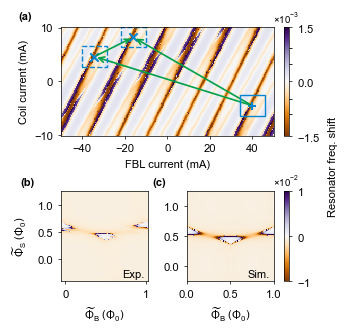

In [15]:


# Exact paper width (inches)
fig = plt.figure(figsize=(3.40457, 3.3), constrained_layout=True)

# 2 rows, 3 columns (last column = colorbars)
gs = GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1, 1, -0.78, 0.06],  # last column = colorbars
    height_ratios=[1.2, 1,],
    wspace=1.4,
    hspace=0.55,
    right = 0.82,
    left = 0.15, 
    top = 0.92, 
    bottom = 0.15
)

# --- TOP PLOT (spans first 2 columns) ---
ax_top = fig.add_subplot(gs[0, 0:2])
cax_top = fig.add_subplot(gs[0,3])


quadmesh = data.plot(
    ax=ax_top,
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    cmap="PuOr",
    rasterized=True,
    add_colorbar=False,
)

cbar = fig.colorbar(
    quadmesh,
    cax=cax_top,
    label='', 
)



formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # always use scientific notation

cbar.ax.yaxis.set_major_formatter(formatter)
vmin, vmax = quadmesh.get_clim()
cbar.set_ticks([vmin, 0, vmax])
offset = cbar.ax.yaxis.get_offset_text()
offset.set_size(7)
offset.set_x(3)


# --- your annotations (same as before) ---
detection_marker = ax_top.scatter(*vertices_scaled.T, c='#0485d1', marker='x')
kernel_marker = ax_top.scatter(*kernel_center_scaled, c='#0485d1', marker='+')

for vx, vy in vertices_scaled:
    arrow = FancyArrowPatch(
        posA=kernel_center_scaled,
        posB=(vx, vy),
        arrowstyle="->",
        color="#01a049",
        mutation_scale=10,
        lw=1.2,
    )
    ax_top.add_patch(arrow)

rect_width = (kernel_extents_scaled[1] - kernel_extents_scaled[0])
rect_height = (kernel_extents_scaled[3] - kernel_extents_scaled[2])

for (vx, vy) in [*vertices_scaled, kernel_center_scaled]:
    linestyle = '-' if (vx, vy) == tuple(kernel_center_scaled) else '--'

    rect_patch = mpl.patches.Rectangle(
        (vx - rect_width/2, vy - rect_height/2),
        width=rect_width,
        height=rect_height,
        fill=None,
        edgecolor='#0485d1',
        linestyle=linestyle,
    )
    ax_top.add_patch(rect_patch)

for (i, (x0, y0)), (j, (x1, y1)) in combinations(enumerate(vertices_scaled), 2):
    ax_top.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="<-",
            color='#01a049',
            lw=1.2,
            alpha=1,
        ),
    )
# ax_top.set_title("Detected repeated features")
ax_top.set_xlabel("FBL current (mA)")
ax_top.set_ylabel("Coil current (mA)")


# --- BOTTOM RIGHT ---

ax_br = fig.add_subplot(gs[1, 1])

im = ax_br.imshow(
    chi_min_2d.T,
    origin='lower',
    extent=[flux1_vals.min(), flux1_vals.max(),
            flux2_vals.min(), flux2_vals.max()],
    aspect='auto',
    cmap="PuOr",
    vmin=-0.01,
    vmax=0.01,
)

ax_br.set_xlabel(r"$\widetilde{\Phi}_{\mathrm{B}}$ ($\Phi_0$)")
# --- BOTTOM LEFT ---
ax_bl = fig.add_subplot(gs[1, 0])

mappable = data2.plot(
    ax=ax_bl,
    cmap="PuOr",
    add_colorbar=False,  # important: avoid duplicate colorbar
    rasterized=True,
    vmin=-0.01,
    vmax=0.01,

)

ax_bl.set_xlabel(r"$\widetilde{\Phi}_{\mathrm{B}}$ ($\Phi_0$)")
ax_bl.set_ylabel(r"$\widetilde{\Phi}_{\mathrm{S}}$ ($\Phi_0$)")

# --- SHARED COLORBAR FOR BOTTOM ROW ---
cax_bottom = fig.add_subplot(gs[1, 3])

cbar2 = fig.colorbar(
    mappable,  # or choose data2 plot if preferred
    cax=cax_bottom,
    label='', 
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # always use scientific notation

cbar2.ax.yaxis.set_major_formatter(formatter)
cbar2.set_ticks([-0.01, 0, 0.01])
offset = cbar2.ax.yaxis.get_offset_text()
offset.set_size(7)
offset.set_x(3)


fig.text(
    0.95, 0.5,  # adjust x-position slightly depending on layout
    "Resonator freq. shift",
    rotation=90,
    va="center",
    ha="center"
)
fig.align_ylabels([ax_top, ax_bl])

ax_bl.text(
    0.7, 0.05,
    "Exp.",
    transform=ax_bl.transAxes,
)
ax_br.text(
    0.7, 0.05,
    "Sim.",
    transform=ax_br.transAxes,
)

ax_top.text(
   -0.2, 1.15, "(a)",
    transform=ax_top.transAxes,

    fontweight="bold",
    va="top",
    ha="left"
)

ax_bl.text(
    -0.47, 1.15, "(b)",
    transform=ax_bl.transAxes,

    fontweight="bold",
    va="top",
    ha="left"
)

ax_br.text(
    -0.4, 1.15, "(c)",
    transform=ax_br.transAxes,

    fontweight="bold",
    va="top",
    ha="left"
)
fig.savefig("FigS2_Cross_talk.pdf")
plt.show()